# Learning Weighted Dependencies for Calibration DAGs

This notebook uses a small toy simulation to illustrate a possible extension for calibration workflows: use repeated `check_data`/`diagnose`-like observations to update confidence in candidate dependency edges over time.

**Edge convention:** `u -> v` means calibration routine `u` depends on calibration routine `v`.

## Positioning

This is not intended as a replacement for Optimus or graph-local calibration optimizers. It is a toy implementation of a possible diagnostic layer: use inconsistency traces from check_data/diagnose-like observations to update confidence in dependency edges.

Vanilla Optimus `diagnose` is designed to repair state efficiently, not learn graph topology. The examples below therefore require an extension or override that records additional inconsistency traces.

## Reading guide

The notebook follows the same stages as the script: construct a hidden true DAG, create a noisy weighted prior, simulate drift/check_data observations, update edge weights, then choose an edge-weight threshold subject to a recall guardrail.

Terms used throughout:
- **Edge weight:** confidence that a candidate dependency should exist.
- **Edge-weight threshold:** cutoff used to keep or prune candidate edges.
- **Recall guardrail:** minimum acceptable edge recall used when choosing the edge-weight threshold.
- **Revalidation cost:** drifted routine plus all transitive dependents that would be rechecked/revalidated under the thresholded graph.

This metric is a proxy for validation work, not a hardware timing or pulse-level recalibration measurement.


In [1]:
from pathlib import Path
import json
import os
import sys

import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "simulate_dependency_learning.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from simulate_dependency_learning import (
    SimulationConfig,
    config_for_json,
    cost_curve,
    create_prior_weights,
    edge_recall_metrics,
    generate_hidden_true_dag,
    graph_from_scores,
    mean_revalidation_cost,
    plot_cost_curve,
    plot_pr_curves,
    plot_proposal_summary_figure,
    plot_weight_heatmaps,
    select_edge_weight_threshold,
    simulate_check_data_observations,
    simulate_hidden_event,
    edge_weight_threshold_tradeoff_curve,
    update_weights_from_observations,
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config = SimulationConfig(output_dir=OUTPUT_DIR)
rng = np.random.default_rng(config.seed)
config


SimulationConfig(n_nodes=30, n_events=600, seed=7, p_true=0.08, obs_noise=0.05, output_dir=PosixPath('outputs'), spatial_locality=True, locality_scale=0.35, propagation_prob=0.8, known_true_fraction=0.55, known_false_positive_fraction=0.05, affected_observation_prob=0.95, background_observation_prob=0.25, diagnose_success_prob=0.75, eta_pos=0.65, eta_neg=0.35, eta_neg_mild=0.08, eta_coaffected=0.03)

## Toy model

Given uncertainty about which dependency edges should exist, this toy model starts with a dense weighted candidate DAG. Known or physics-informed prior edges receive high initial weights, spatially local speculative edges receive moderate weights, and other candidate edges receive lower weights. The learner updates these weights dynamically as more synthetic calibration data is collected.

The examples below use the edge convention `u -> v` means calibration routine `u` depends on calibration routine `v`. They also assume an extension or override of vanilla Optimus `diagnose` behavior, because vanilla `diagnose` is designed to repair state efficiently rather than collect extra evidence for graph-topology learning.

One hypothetical structural inconsistency, using a chain of dependencies `E -> D -> C -> B -> A`:
1. Suppose `diagnose` is called on `E`, and `D` is found to have bad data and then brought back into spec.
2. During this process, `diagnose` determines that `C` is already in spec.
3. With the extra diagnostic-layer override, we can continue by checking whether `B` has bad data. If `B` is bad, the candidate edge `C -> B` should have its weight decreased while an alternative edge `D -> B` should have its weight increased.

A second hypothetical example, during a higher-level maintenance loop:
1. Suppose `B` fails `check_state` and is found to be out of spec.
2. Later `C` fails `check_state` after `B` has become miscalibrated.
3. Upon running `check_data`, `C` is found to still be in spec. In this case, the edge `C -> B` would be decreased in weight.


In [2]:
true_graph, true_edges, coords, edges, distances = generate_hidden_true_dag(config, rng)
initial_weights, known_edges, local_mask = create_prior_weights(
    config, rng, edges, true_edges, distances
)

print(f"Nodes: {config.n_nodes}")
print(f"Candidate edges: {len(edges)}")
print(f"Hidden true edges: {len(true_edges)}")
print(f"High-prior known edges: {len(known_edges)}")

Nodes: 30
Candidate edges: 435
Hidden true edges: 34
High-prior known edges: 39


The hidden true edges in the simulation define a DAG, unknown to the learning algorithm, that represents an ideal dependency structure. A dense weighted prior is used as the initial candidate DAG. Known or physics-informed prior edges receive high initial weights, spatially local speculative edges receive moderate weights, and other candidate edges receive lower weights.

## Learning rule

Each simulated event picks one node to drift, propagates miscalibrations through the hidden/ideal DAG, samples noisy data, and updates candidate edge weights in log-odds space.


In [3]:
learned_weights = initial_weights.copy()

for _ in range(config.n_events):
    root, affected, cause_parent = simulate_hidden_event(true_graph, config, rng)
    observed_mask, noisy_state = simulate_check_data_observations(config, affected, root, rng)
    learned_weights = update_weights_from_observations(
        learned_weights,
        edges,
        observed_mask,
        noisy_state,
        cause_parent,
        config,
        rng,
    )

print(f"Ran {config.n_events} synthetic learning events.")

Ran 600 synthetic learning events.


## Results

The main evaluation is edge recall against the hidden DAG. Recall is the fraction of true dependency edges retained by an edge-weight-thresholded graph. Precision is the fraction of retained candidate edges that are actually true dependencies. F1 is the harmonic mean of precision and recall, and AUC-PR summarizes the full precision/recall curve across edge-weight thresholds.

There are two threshold-like quantities in the results. The **edge-weight threshold** is the cutoff applied to candidate edge weights; increasing it prunes more edges from the graph. The **recall guardrail** is not a graph cutoff: it is the minimum acceptable dependency-edge recall used when choosing an edge-weight threshold. Here, the recall guardrail is 0.90.

To choose an edge-weight threshold after learning, we compare dependency-edge recall with revalidation cost: the expected number of routines that would be rechecked/revalidated after a drift. A low revalidation cost at high edge-weight thresholds can be misleading if it comes from pruning real dependencies, because those missing edges can skip needed downstream revalidations. Here, the selected edge-weight threshold minimizes estimated revalidation cost while satisfying the recall guardrail.


In [4]:
labels = np.array([1 if edge in true_edges else 0 for edge in edges], dtype=int)
initial_metrics = edge_recall_metrics(labels, initial_weights)
learned_metrics = edge_recall_metrics(labels, learned_weights)

cost_rng = np.random.default_rng(config.seed + 10_001)
edge_weight_thresholds, prior_costs, learned_costs, true_cost, roots = cost_curve(
    config, true_graph, edges, initial_weights, learned_weights, cost_rng
)
prior_tradeoff = edge_weight_threshold_tradeoff_curve(config, edges, labels, initial_weights, roots, edge_weight_thresholds)
learned_tradeoff = edge_weight_threshold_tradeoff_curve(config, edges, labels, learned_weights, roots, edge_weight_thresholds)
recall_guardrail = 0.90
selected = select_edge_weight_threshold(learned_tradeoff, recall_guardrail=recall_guardrail)

prior_graph_05 = graph_from_scores(config.n_nodes, edges, initial_weights, 0.5)
learned_graph_05 = graph_from_scores(config.n_nodes, edges, learned_weights, 0.5)
revalidation_cost_prior_05 = mean_revalidation_cost(prior_graph_05, roots)
revalidation_cost_learned_05 = mean_revalidation_cost(learned_graph_05, roots)

print(f"AUC-PR: initial={initial_metrics['auc_pr']:.3f}, learned={learned_metrics['auc_pr']:.3f}")
print(f"Best F1: initial={initial_metrics['best_f1']:.3f}, learned={learned_metrics['best_f1']:.3f}")
print(
    "Selected edge-weight threshold: "
    f"{selected['selected_edge_weight_threshold']:.2f}; "
    f"precision={selected['precision']:.3f}, "
    f"recall={selected['recall']:.3f}, "
    f"recall guardrail={selected['recall_guardrail']:.2f}, "
    f"F1={selected['f1']:.3f}, "
    f"revalidation cost={selected['revalidation_cost']:.2f}"
)
print(
    "Mean revalidation cost @0.5: "
    f"true={true_cost:.2f}, prior={revalidation_cost_prior_05:.2f}, "
    f"learned={revalidation_cost_learned_05:.2f}"
)


AUC-PR: initial=0.334, learned=0.965
Best F1: initial=0.521, learned=0.955
Selected edge-weight threshold: 0.34; precision=1.000, recall=0.912, recall guardrail=0.90, F1=0.954, revalidation cost=4.77
Mean revalidation cost @0.5: true=4.96, prior=6.15, learned=4.77


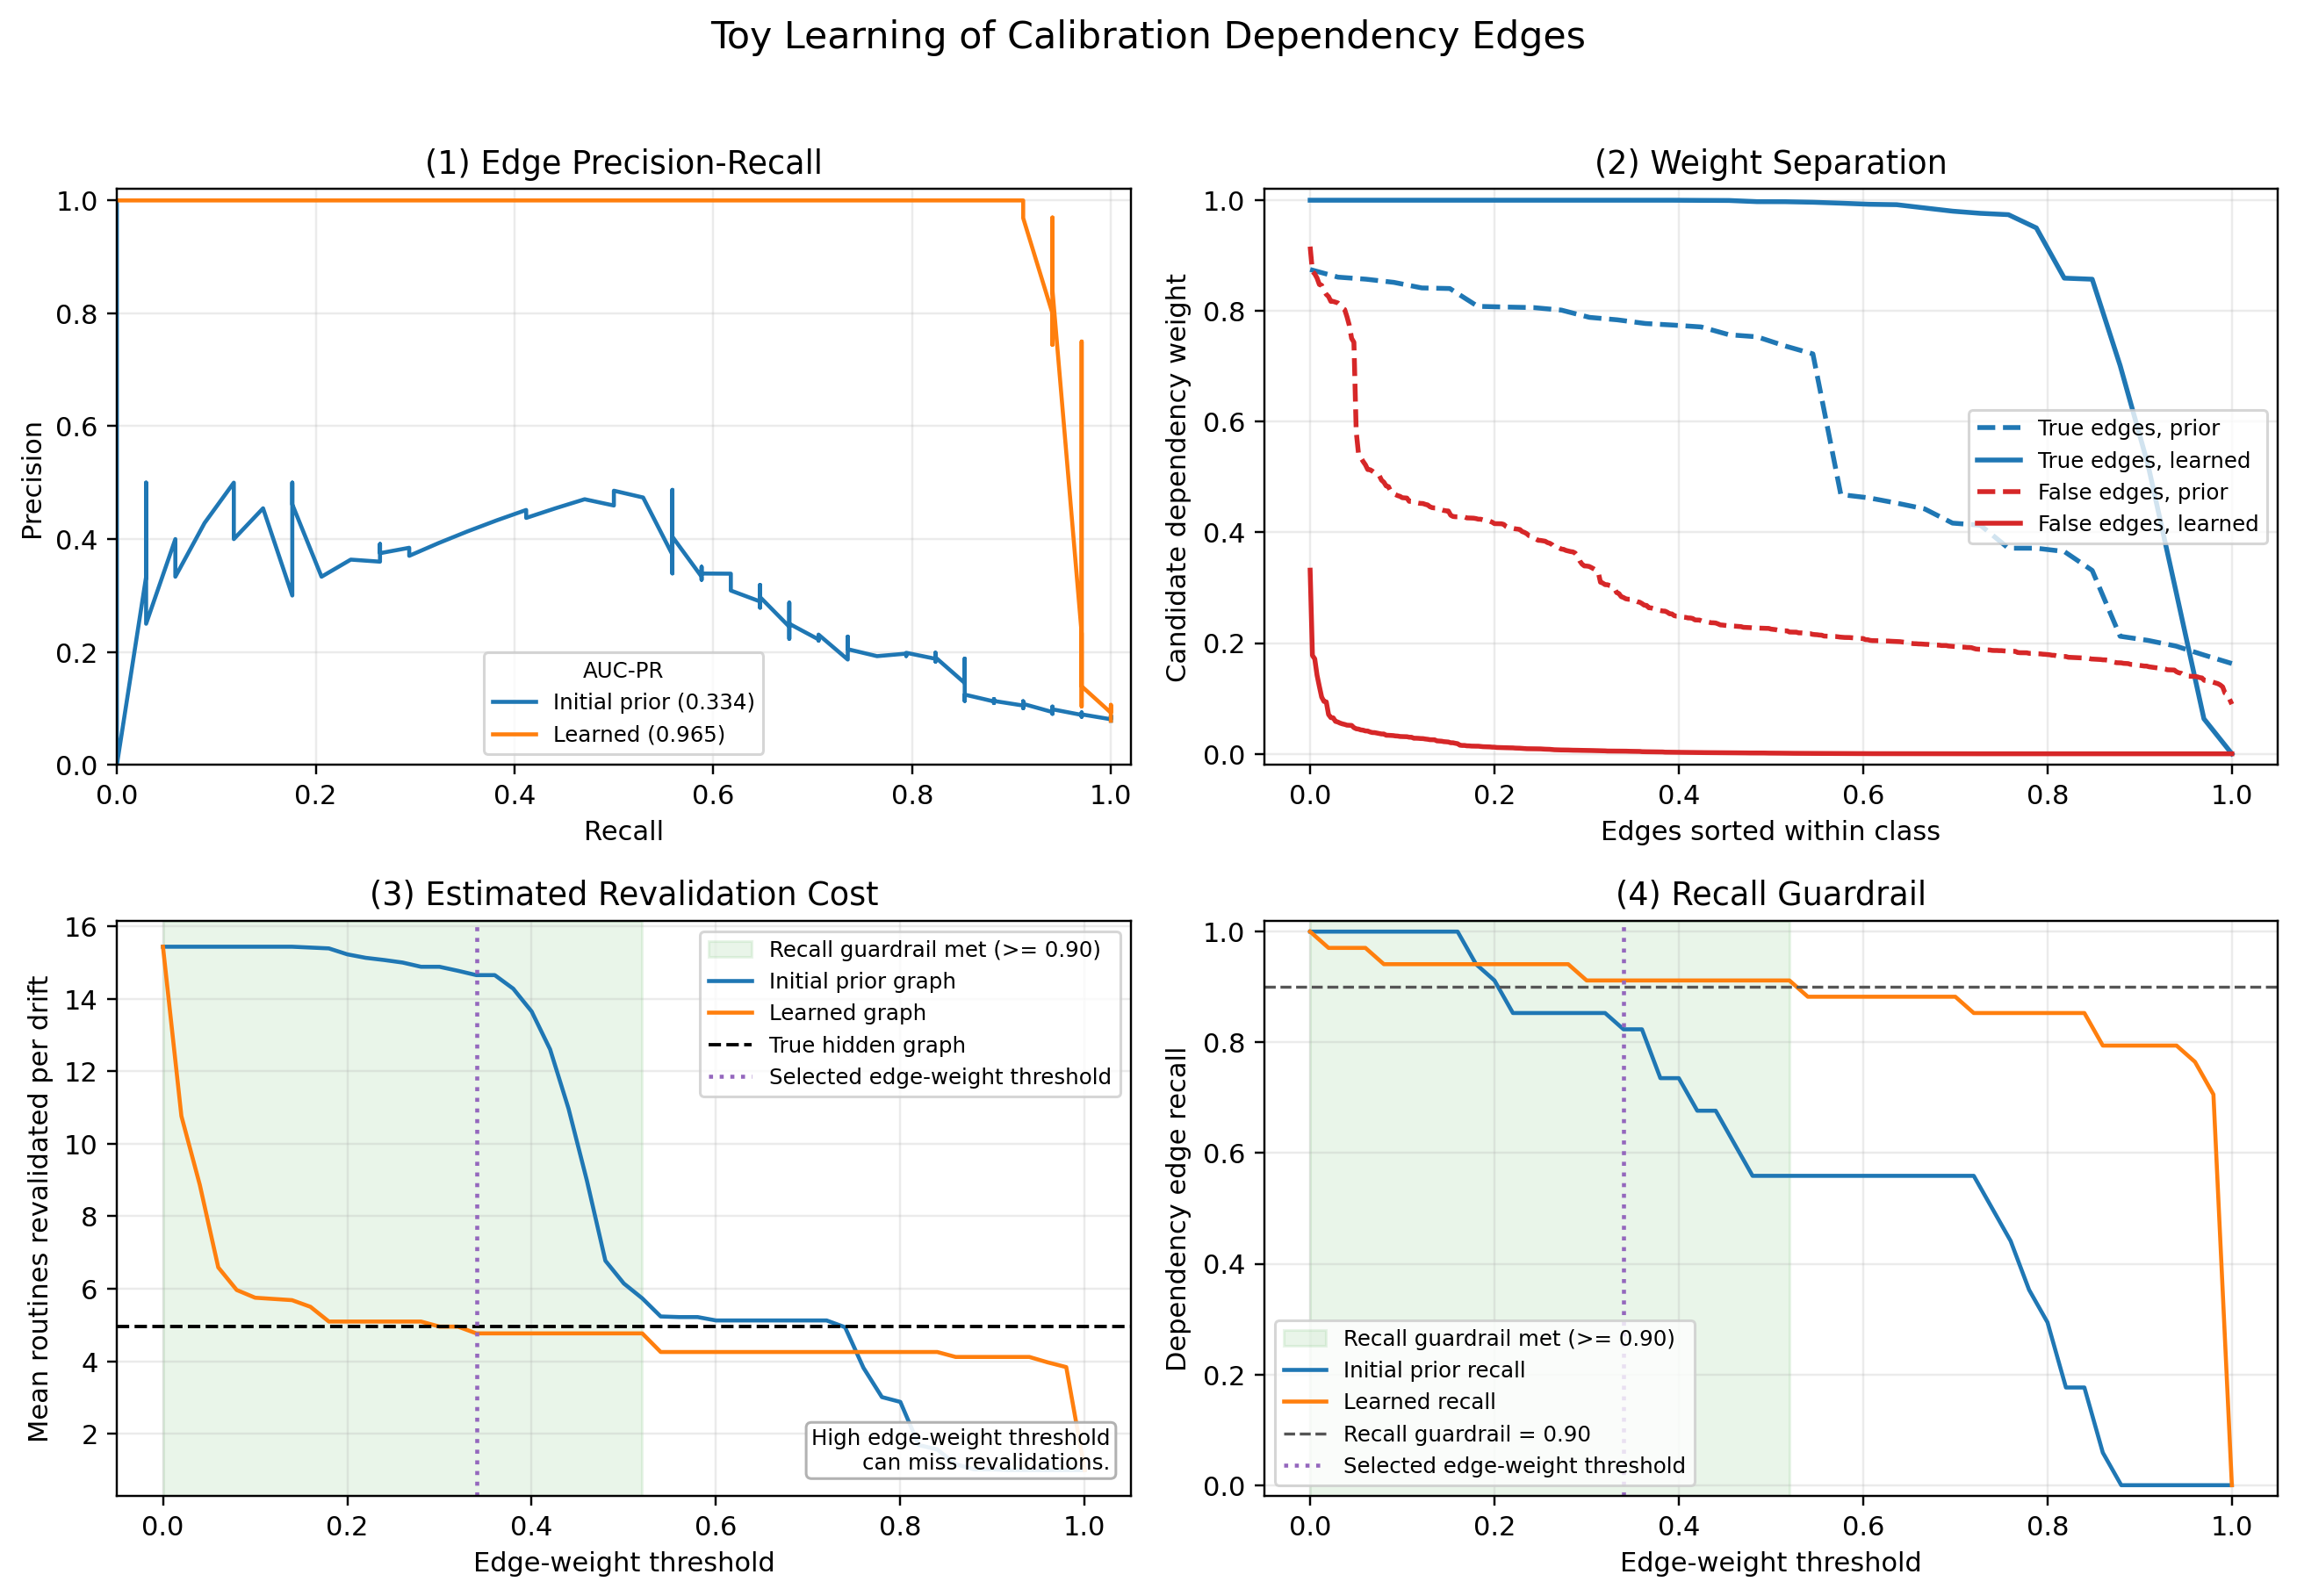

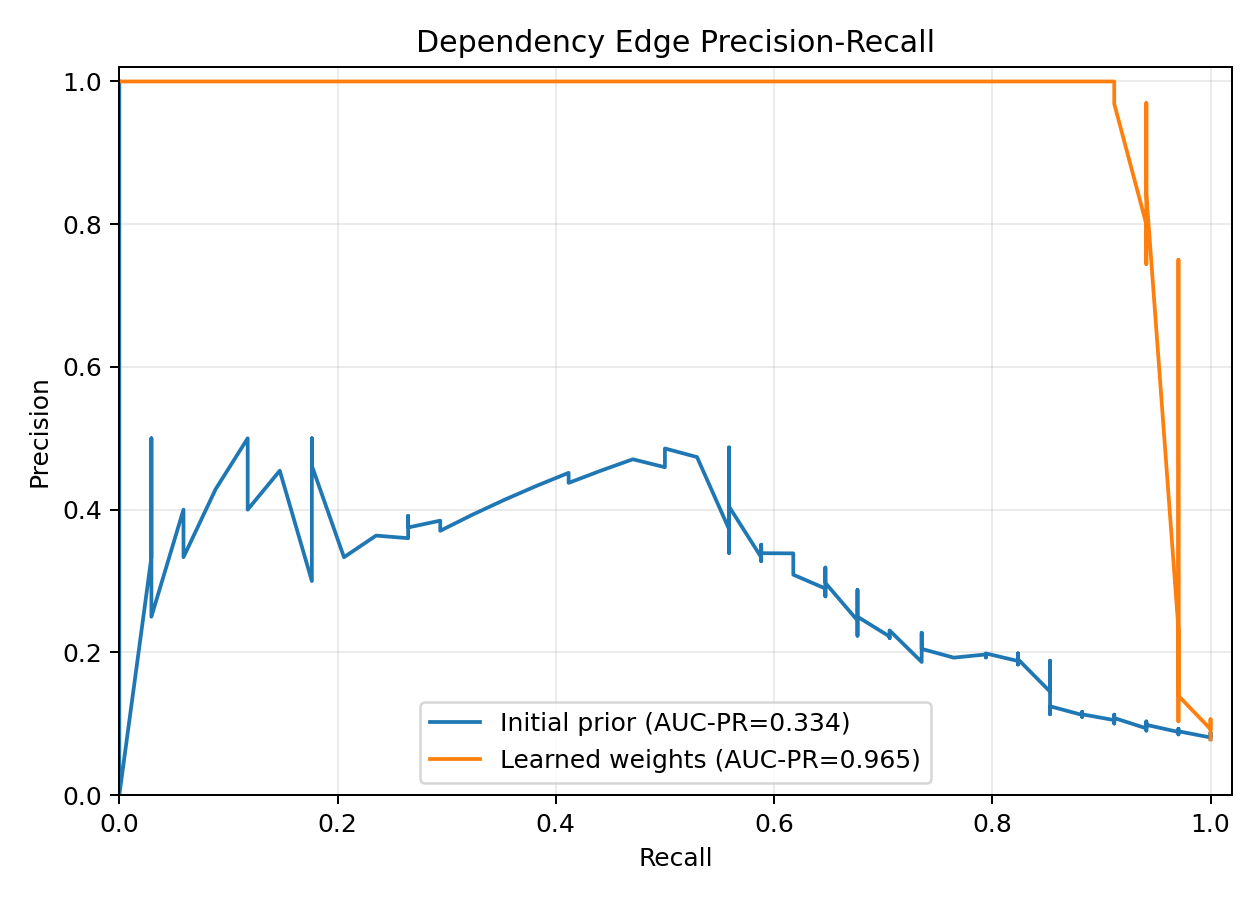

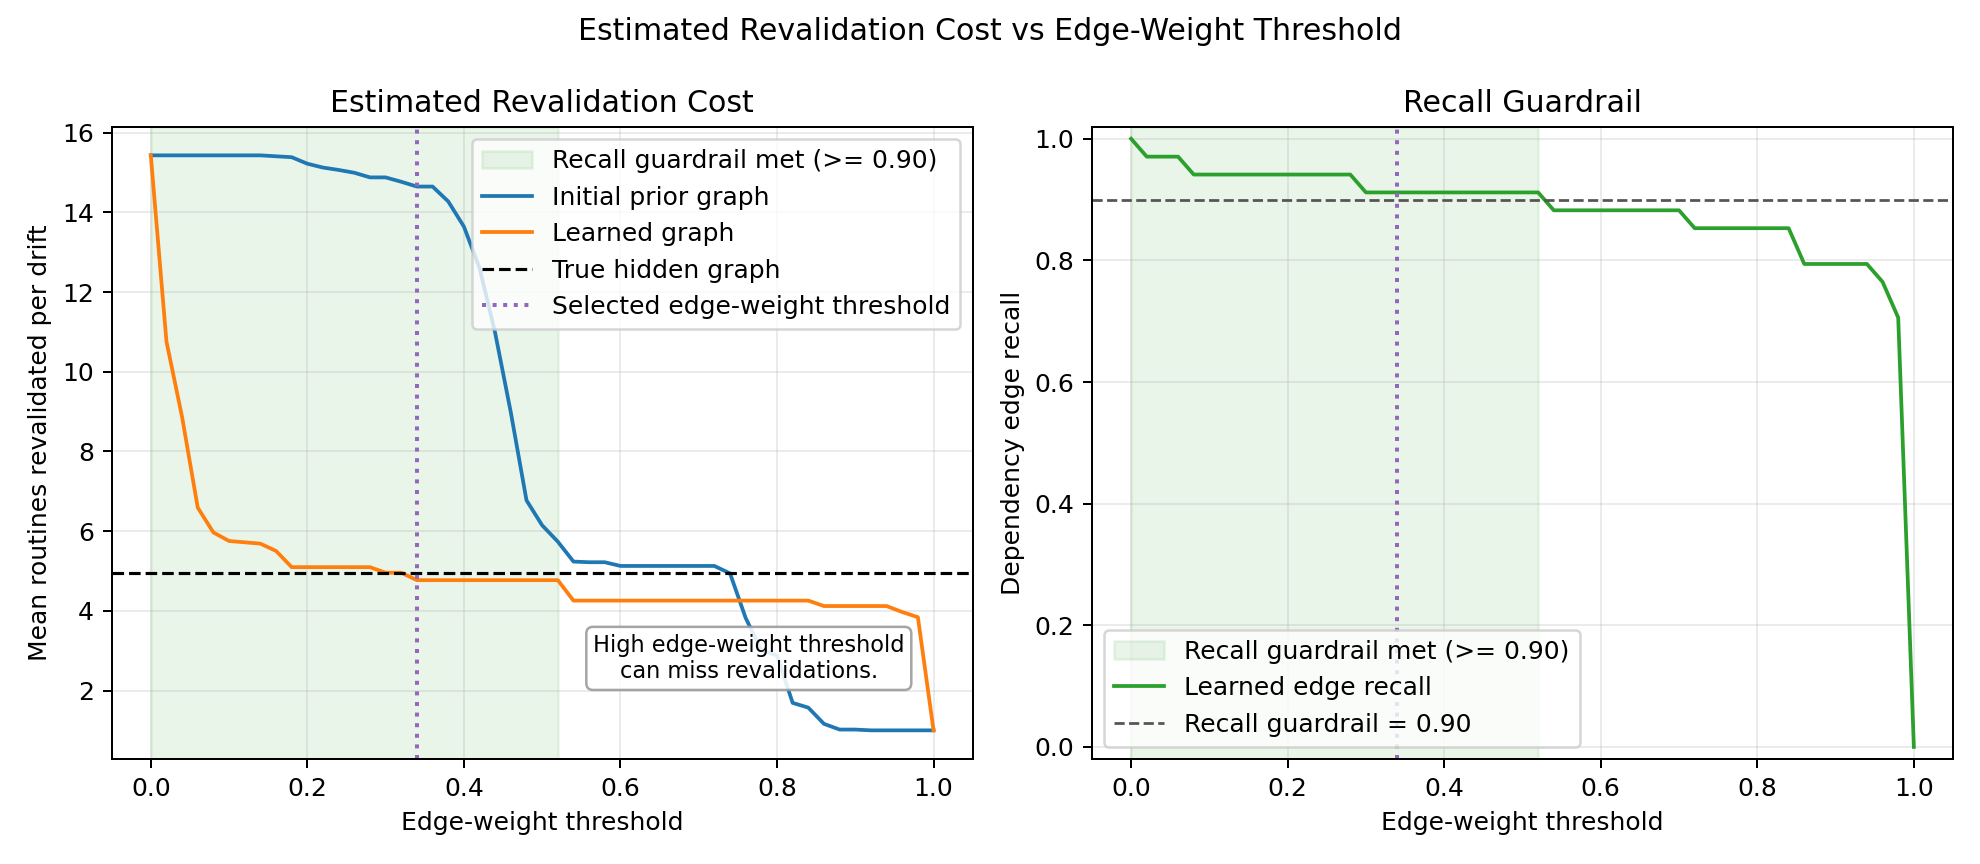

In [5]:
plot_pr_curves(labels, initial_weights, learned_weights, OUTPUT_DIR / "edge_precision_recall_curve.png")
plot_weight_heatmaps(
    config.n_nodes,
    edges,
    true_edges,
    initial_weights,
    learned_weights,
    OUTPUT_DIR / "edge_weight_heatmap_before_after.png",
)
plot_cost_curve(
    edge_weight_thresholds,
    prior_costs,
    learned_costs,
    true_cost,
    np.array(learned_tradeoff["edge_recall"], dtype=float),
    float(selected["selected_edge_weight_threshold"]),
    OUTPUT_DIR / "cost_recall_tradeoff.png",
    recall_guardrail=recall_guardrail,
)
plot_proposal_summary_figure(
    labels,
    initial_weights,
    learned_weights,
    edge_weight_thresholds,
    prior_costs,
    learned_costs,
    true_cost,
    np.array(prior_tradeoff["edge_recall"], dtype=float),
    np.array(learned_tradeoff["edge_recall"], dtype=float),
    float(selected["selected_edge_weight_threshold"]),
    OUTPUT_DIR / "proposal_summary_figure.png",
    recall_guardrail=recall_guardrail,
)

metrics = {
    "initial_auc_pr": initial_metrics["auc_pr"],
    "learned_auc_pr": learned_metrics["auc_pr"],
    "initial_best_f1": initial_metrics["best_f1"],
    "learned_best_f1": learned_metrics["best_f1"],
    "revalidation_cost_prior_at_edge_weight_threshold_0_5": revalidation_cost_prior_05,
    "revalidation_cost_learned_at_edge_weight_threshold_0_5": revalidation_cost_learned_05,
    "revalidation_cost_true": true_cost,
    "selected_edge_weight_threshold": selected["selected_edge_weight_threshold"],
    "selected_edge_weight_threshold_metrics": selected,
    "edge_weight_threshold_curves": {
        "initial_prior": prior_tradeoff,
        "learned": learned_tradeoff,
    },
    "config": config_for_json(config),
}
with (OUTPUT_DIR / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)
    handle.write("\n")

for figure_path in [
    OUTPUT_DIR / "proposal_summary_figure.png",
    OUTPUT_DIR / "edge_precision_recall_curve.png",
    OUTPUT_DIR / "cost_recall_tradeoff.png",
]:
    display(Image(filename=str(figure_path)))


In the 4-panel summary figure, the panel titles correspond to this sequence: (1) precision/recall quality for the initial prior versus learned weights, (2) separation between true and false edge weights, (3) estimated revalidation cost as the edge-weight threshold changes, and (4) the recall guardrail used to choose the selected edge-weight threshold.


## Interpretation

In this controlled toy setting, the learned weights separate hidden true dependencies from false candidates more cleanly than the initial prior. The selected edge-weight threshold satisfies the recall guardrail while reducing the estimated revalidation cost relative to the dense prior. This means the learner is not only assigning larger weights to true dependencies, but is also finding an operating point where pruning low-weight edges does not delete many true downstream validation relationships.

The cost and recall panels should be read together. Revalidation cost usually falls as the edge-weight threshold rises because fewer edges remain in the graph, but that improvement is useful only while the recall guardrail remains satisfied. Once recall drops below the guardrail, the apparent cost reduction can mean the graph is missing real dependencies and would fail to trigger some needed revalidations after a drift.


## Limitations

- Observations are synthetic, not hardware measurements.
- Drift propagation is a simple probabilistic graph process.
- There is no real pulse/control data and no Optimus integration.
- The update rule is heuristic rather than physically derived.
- The diagnostic-layer examples require an extension or override of vanilla `diagnose` behavior.
- The method may require a relatively high overhead of data collection when initially determining which dependencies should exist.


## Reproduce

Run the notebook top to bottom, or run the script from the repository root:

```bash
python simulate_dependency_learning.py
```

Use `python simulate_dependency_learning.py --help` for configurable toy parameters such as node count, event count, noise, seed, output directory, spatial locality, and propagation probability.

The key artifacts are `outputs/proposal_summary_figure.png`, `outputs/edge_precision_recall_curve.png`, `outputs/cost_recall_tradeoff.png`, and `outputs/metrics.json`.